<a href="https://colab.research.google.com/github/COMP3608-Group-12/Project/blob/Logistic-Regression-Algorithm-Dataset-1/Group_12_Dataset_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Initial test commit

## STEP 1: Importing Packages

In [1]:
#importing packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import imblearn

## STEP 2: Load & Understand Data

In [2]:
#loading csv file into pandas dataframe
df = pd.read_csv('creditcard.csv')

#printing dataset information (how many rows, columns etc)
print(df.info())
print('----------------------------------------------------------')

#checking if any values are missing
print(df.isnull().sum())
print('----------------------------------------------------------')

#printing first 5 rows of data to ensure it correlates with datafile
print(df.head(5))
print('----------------------------------------------------------')

#checking how many transactions are fraudulent and how many are non-fraudulent
print(df['Class'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

## Step 3: Split Data (80/20)

In [3]:
#Dropping time column as it is not necessary for prediction
df = df.drop('Time', axis=1)

#Splitting features and target
X = df.drop('Class', axis=1)
y = df['Class']

#Splitting the data into training and test data 80/20 split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Before Resampling:")
print(y_train.value_counts())

Before Resampling:
Class
0    227451
1       394
Name: count, dtype: int64


## Step 4: Apply SMOTE to balance the data

In [4]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to the training data(to balance)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("After Resampling(SMOTE):")
print(y_train_resampled.value_counts())

After Resampling(SMOTE):
Class
0    227451
1    227451
Name: count, dtype: int64


## Step 5: Applying and Evaluating Decision Tree Algorithm

### Step 5a: Training the Decision Tree Model

In [ ]:
#Training Decision Tree Model
from sklearn.tree import DecisionTreeClassifier, plot_tree

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train_resampled, y_train_resampled)

#NOTE: the hyperparameters for the DecisionTreeClassifier were chosen through trial and error (ended up being none)
#Possible future enhancements can be to possibly do hyperparameter tuning using GridSearchCV or RandomizedSearchCV

DecisionTreeClassifier(random_state=42)

### Step 5b: Make Predictions

In [ ]:
#Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

y_pred_train = model.predict(X_train_resampled)
y_prob_train = model.predict_proba(X_train_resampled)[:, 1]

### Step 5c: Evaluating the model using performance metrics

In [ ]:
#Evaluating the model using performance metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

#Calculating performance metrics
results = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_prob)
}

#Printing results in an easy to read table
results_df = pd.DataFrame({"Metric": list(results.keys()), "Value": [round(value, 4) for value in results.values()]})
print(results_df)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

      Metric   Value
0   Accuracy  0.9982
1  Precision  0.4848
2     Recall  0.8163
3   F1 Score  0.6084
4    ROC-AUC  0.9074
Confusion Matrix:
[[56779    85]
 [   18    80]]
Classification Report:
              precision    recall  f1-score   support

           0     0.9997    0.9985    0.9991     56864
           1     0.4848    0.8163    0.6084        98

    accuracy                         0.9982     56962
   macro avg     0.7423    0.9074    0.8037     56962
weighted avg     0.9988    0.9982    0.9984     56962



### Step 5d: Checking for Overfitting
Decision Trees are prone to overfitting i.e. the model performs much better on the training data than it does on the test data.

Hence, we will check if it generalizes well by comparing the accuracy metrics of how the model performed on both the training and test data.

In [ ]:
print("Accuracy of Model on Train Data:")
print(round(accuracy_score(y_train_resampled, y_pred_train), 4))

print("Accuracy of Model on Test Data:")
print(round(accuracy_score(y_test, y_pred), 4))


Accuracy of Model on Train Data:
1.0
Accuracy of Model on Test Data:
0.9982


### Step 5e: Visualising the Decision Tree

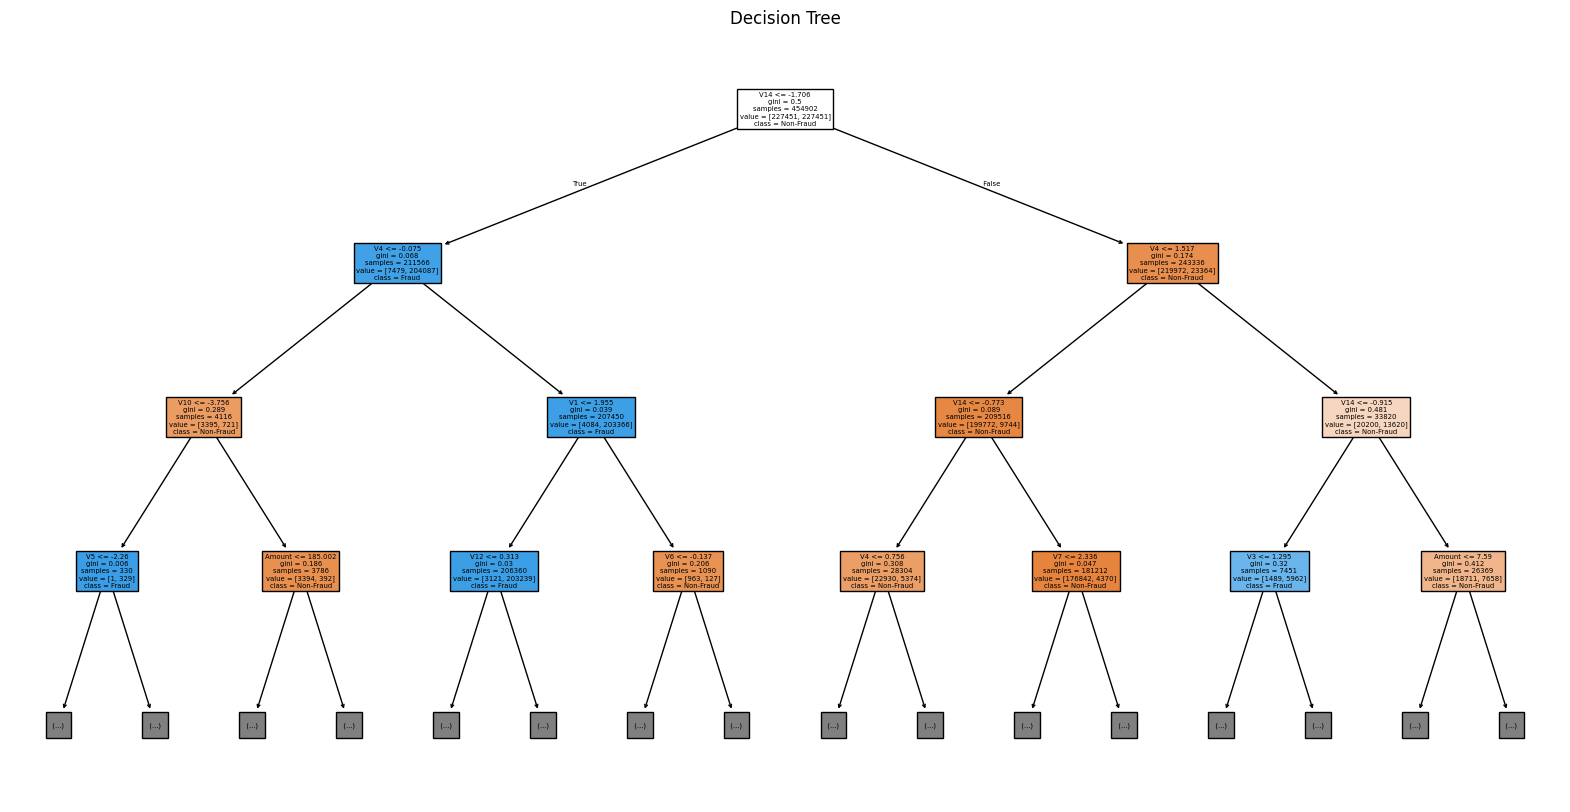

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(model, feature_names= X_train_resampled.columns, class_names= ["Non-Fraud", "Fraud"], filled=True, max_depth=3)
plt.title("Decision Tree")
plt.show()

## Step 6: Deep Neural Network

## Step 7: Logistic Regression

###Step 7a: Train the Logistic Regression Model

In [5]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_resampled, y_train_resampled)

LogisticRegression(max_iter=1000, random_state=42)

###Step 7b: Making Predictions

In [6]:
#Predictions
y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)[:, 1]

###Step 7c: Evaluating the Model Using Performance Metrics

In [7]:
#Evaluating the model using performance metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

#Calculating performance metrics
results = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_prob)
}

#Printing results in an easy to read table
results_df = pd.DataFrame({"Metric": list(results.keys()), "Value": [round(value, 4) for value in results.values()]})
print(results_df)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

      Metric   Value
0   Accuracy  0.9812
1  Precision  0.0772
2     Recall  0.9082
3   F1 Score  0.1423
4    ROC-AUC  0.9719
Confusion Matrix:
[[55800  1064]
 [    9    89]]
Classification Report:
              precision    recall  f1-score   support

           0     0.9998    0.9813    0.9905     56864
           1     0.0772    0.9082    0.1423        98

    accuracy                         0.9812     56962
   macro avg     0.5385    0.9447    0.5664     56962
weighted avg     0.9983    0.9812    0.9890     56962

